STEP 1: Import Libraries & Styling

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Styling
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (14,7)
MAIN_COLOR = 'red'

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sav13\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


STEP 2: Load Dataset

In [2]:
df = pd.read_csv(r'C:\Users\sav13\OneDrive\Desktop\futureinterns\TASK-2\IT Service Ticket Classification Dataset\IT Service Ticket Classification Dataset.csv')

df = df[['Document', 'Topic_group']]
df.rename(columns={'Document': 'text', 'Topic_group': 'category'}, inplace=True)

df.dropna(inplace=True)
print(df)

                                                    text       category
0      connection with icon icon dear please setup ic...       Hardware
1      work experience user work experience user hi w...         Access
2      requesting for meeting requesting meeting hi p...       Hardware
3      reset passwords for external accounts re expir...         Access
4      mail verification warning hi has got attached ...  Miscellaneous
...                                                  ...            ...
47832  git space for a project issues with adding use...         Access
47833  error sent july error hi guys can you help out...  Miscellaneous
47834  connection issues sent tuesday july connection...       Hardware
47835  error cube reports sent tuesday july error hel...     HR Support
47836  running out on extensions hello please be advi...       Hardware

[47837 rows x 2 columns]


STEP 3: Dataset Overview Table

In [3]:
print("Shape:", df.shape)
print(df['category'].value_counts())

Shape: (47837, 2)
category
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


STEP 4: Category Distribution

c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


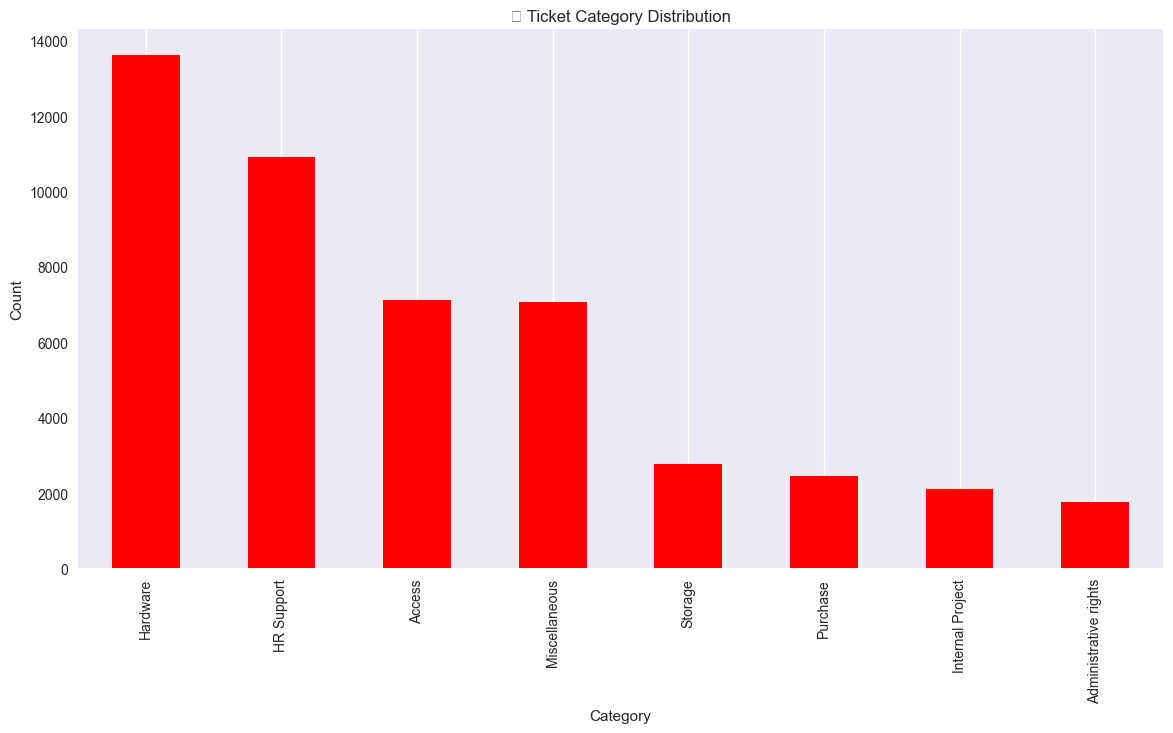

In [4]:
df['category'].value_counts().plot(kind='bar', color=MAIN_COLOR)

plt.title("📊 Ticket Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()

This graph shows which types of issues occur most frequently, helping prioritize resources.
Most issues are technical (hardware + HR), so teams should focus resources there.

STEP 5: Text Length Analysis

c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


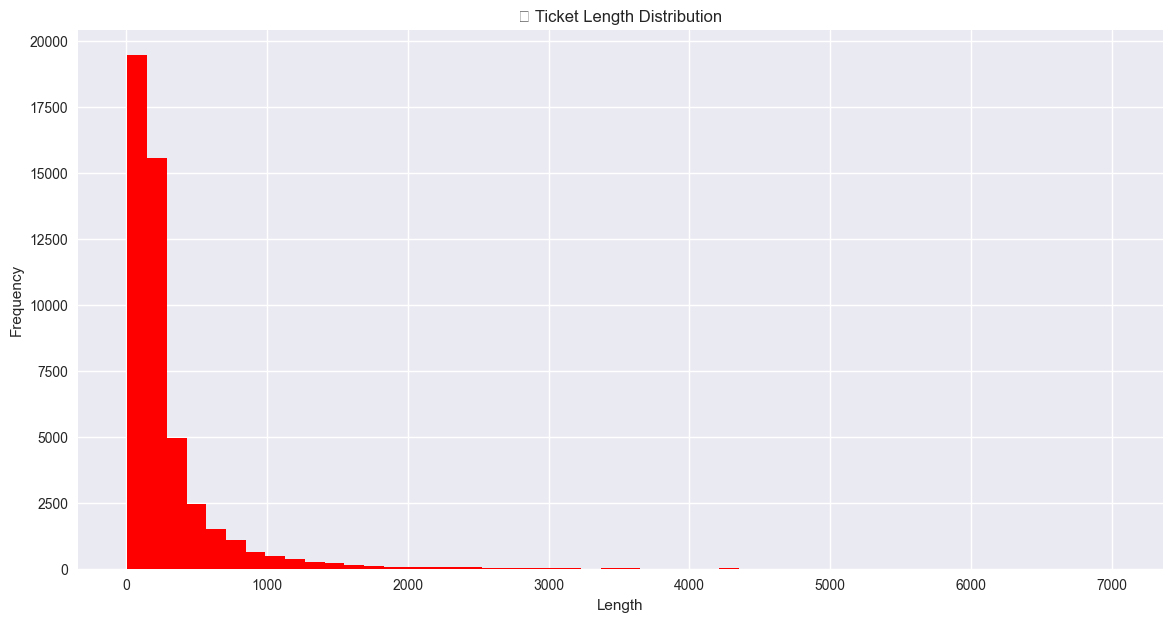

In [5]:
df['text_length'] = df['text'].apply(len)

plt.hist(df['text_length'], bins=50, color=MAIN_COLOR)

plt.title("📊 Ticket Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

This shows how long ticket descriptions are, helping understand user behavior and complexity of issues.

STEP 6: Text Cleaning

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

STEP 7: Word Frequency Table

In [7]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
word_counts = Counter(all_words)

word_df = pd.DataFrame(word_counts.most_common(30), columns=['Word','Frequency'])
word_df

,Word,Frequency
0,please,70212
1,pm,28902
2,hi,28498
3,regards,27212
4,thank,24962
5,hello,23025
6,thanks,19852
7,sent,14717
8,kind,13241
9,access,13153


Shows the most common words in tickets, helping understand frequent issues.

STEP 8: Feature Extraction (TF-IDF)

In [8]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
y = df['category']

STEP 9: Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

STEP 10: Model Training

In [10]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

STEP 11: Predictions

In [11]:
y_pred = model.predict(X_test)

STEP 12: Accuracy + Metrics Table

In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred))

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

report_df.style.background_gradient(cmap='Reds').format("{:.2f}")

Accuracy: 0.850752508361204


,precision,recall,f1-score,support
Access,0.92,0.84,0.88,1416.00
Administrative rights,0.89,0.64,0.74,346.00
HR Support,0.86,0.86,0.86,2241.00
Hardware,0.78,0.90,0.84,2707.00
Internal Project,0.93,0.76,0.84,420.00
Miscellaneous,0.84,0.83,0.83,1388.00
Purchase,0.97,0.89,0.93,505.00
Storage,0.93,0.81,0.87,545.00
accuracy,0.85,0.85,0.85,0.85
macro avg,0.89,0.82,0.85,9568.00


The system is reliable and can automate most ticket classification with high accuracy.

STEP 13: Confusion Matrix

c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


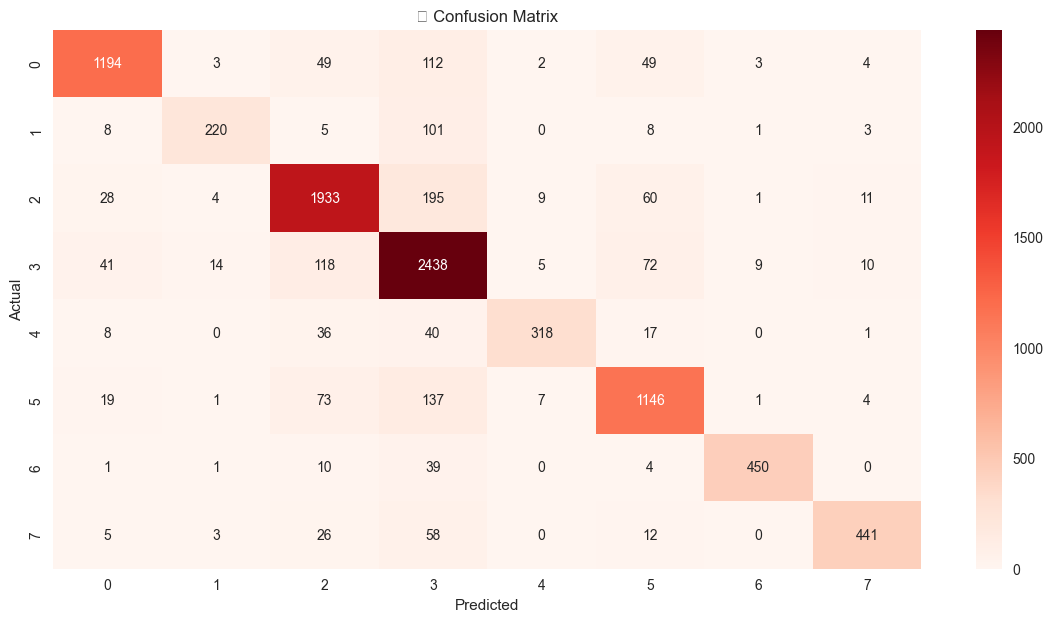

In [13]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

plt.title("📊 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Shows correct and incorrect predictions, helping identify model weaknesses.
The model performs well overall but struggles with categories that have similar wording.

STEP 14: Priority Assignment

In [14]:
def assign_priority(text):
    text = text.lower()
    
    if any(w in text for w in ['urgent','error','failure']):
        return 'High'
    elif any(w in text for w in ['slow','delay','issue','problem']):
        return 'Medium'
    else:
        return 'Low'

df['priority'] = df['text'].apply(assign_priority)

STEP 15: Priority Distribution

c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


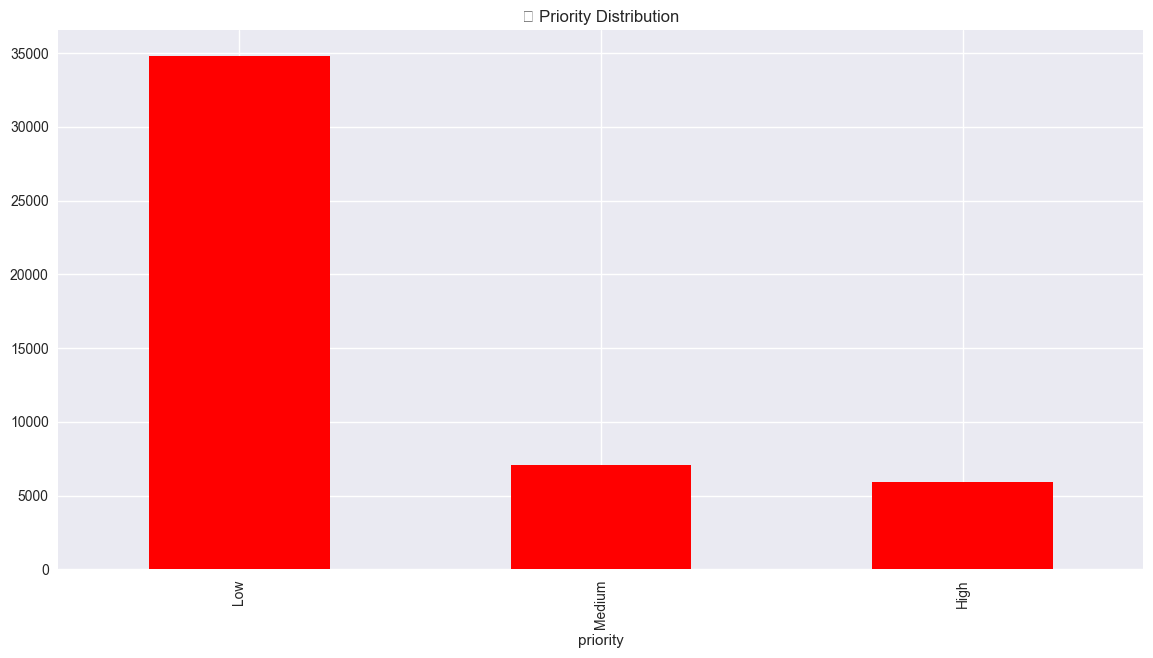

In [15]:
df['priority'].value_counts().plot(kind='bar', color=MAIN_COLOR)

plt.title("🚨 Priority Distribution")
plt.show()

Shows urgency distribution, helping manage workload.
Your system is classifying most tickets as low urgency, which suggests either routine issues dominate or priority rules may be slightly conservative.

STEP 16: Category vs Priority Heatmap

c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


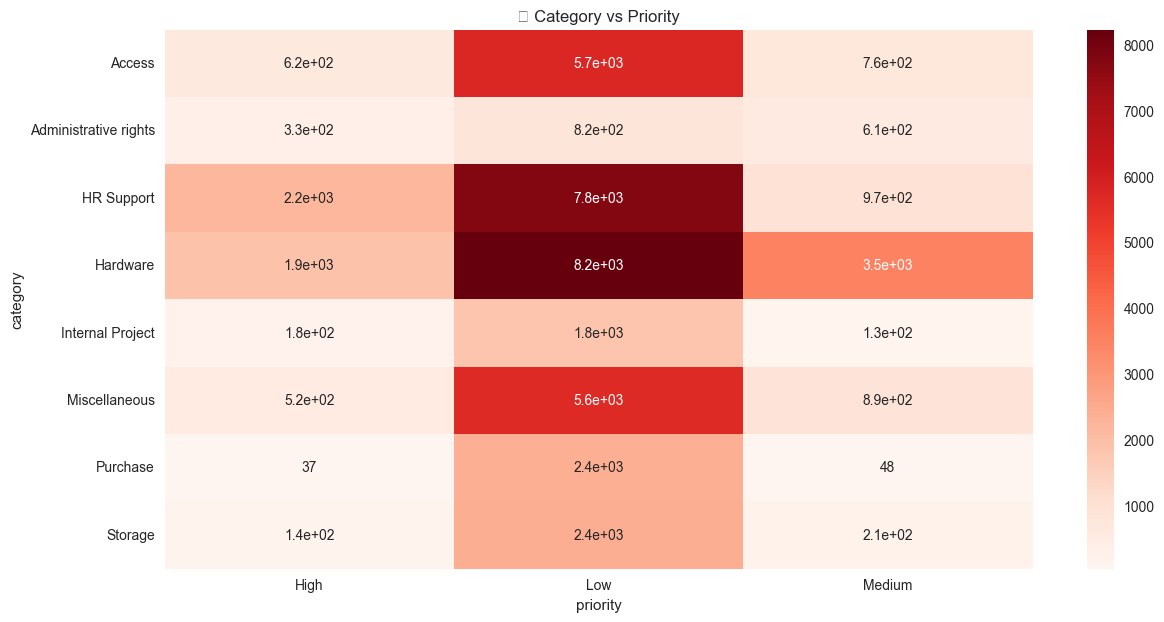

In [16]:
pivot = pd.crosstab(df['category'], df['priority'])

sns.heatmap(pivot, annot=True, cmap='Reds')

plt.title("📊 Category vs Priority")
plt.show()

Shows which types of issues are most critical.
Hardware issues are both frequent and critical → should be prioritized operationally.

STEP 17: Top Influential Words

c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


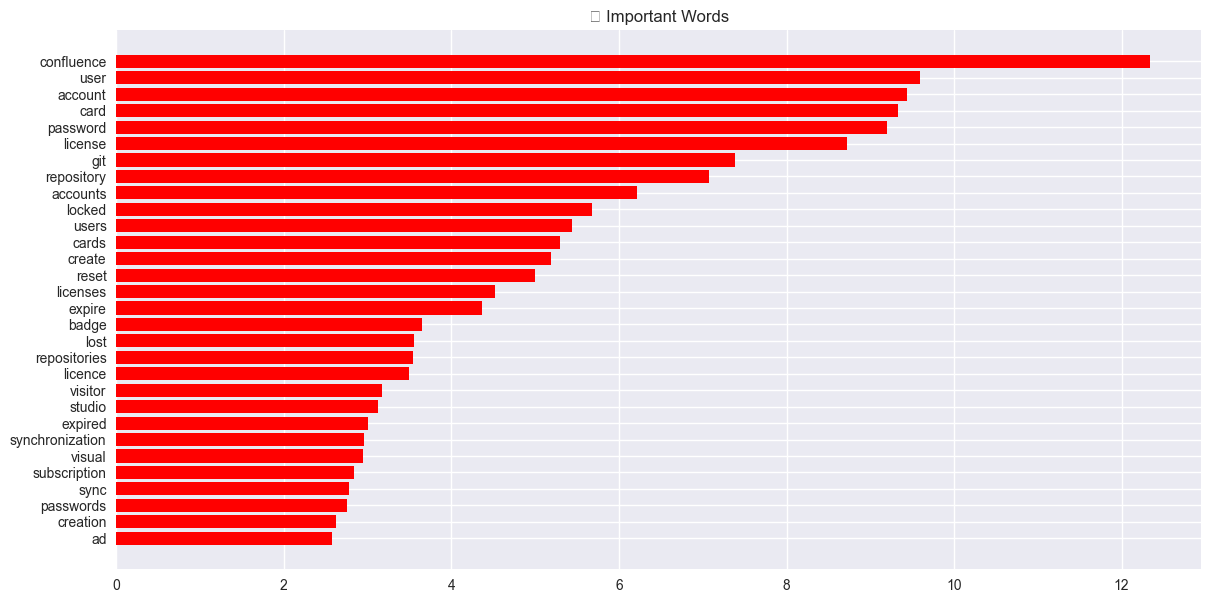

In [17]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_words = pd.DataFrame({
    'Word': feature_names,
    'Importance': coefficients
}).sort_values(by='Importance', ascending=False).head(30)

plt.barh(top_words['Word'], top_words['Importance'], color=MAIN_COLOR)
plt.gca().invert_yaxis()
plt.title("🔍 Important Words")
plt.show()

Shows how the model makes decisions using important keywords.

STEP 18: Prediction System

In [18]:
def predict_ticket(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    
    category = model.predict(vec)[0]
    priority = assign_priority(text)
    
    return category, priority

print(predict_ticket("My system is not working"))

('Hardware', 'Low')


Class-wise Accuracy Table

In [19]:
class_acc = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

class_acc['Correct'] = class_acc['Actual'] == class_acc['Predicted']

classwise = class_acc.groupby('Actual')['Correct'].mean().reset_index()
classwise.rename(columns={'Correct': 'Accuracy'}, inplace=True)

# Style safely (only numeric column)
styled = classwise.style \
    .background_gradient(cmap='Reds', subset=['Accuracy']) \
    .format({'Accuracy': "{:.2f}"}) \
    .set_caption("📊 Class-wise Accuracy")

styled

,Actual,Accuracy
0,Access,0.84
1,Administrative rights,0.64
2,HR Support,0.86
3,Hardware,0.90
4,Internal Project,0.76
5,Miscellaneous,0.83
6,Purchase,0.89
7,Storage,0.81


This table shows how accurately each ticket category is predicted. It helps identify categories where the model performs well or needs improvement.

Precision vs Recall Comparison

c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


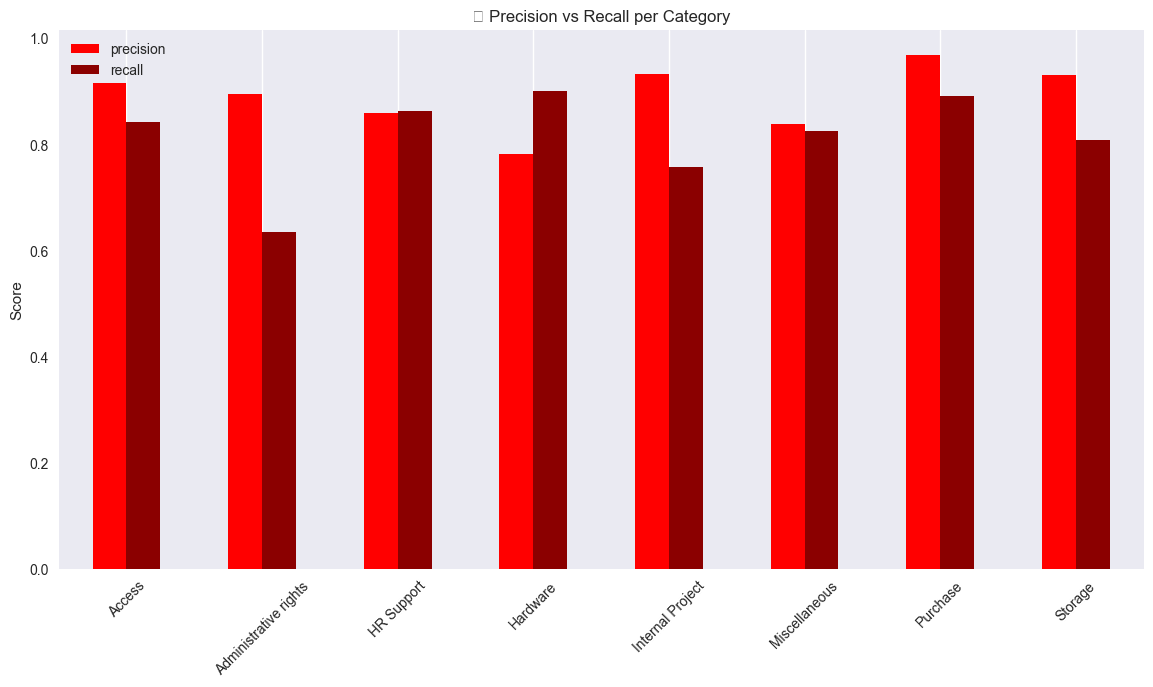

In [20]:
report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()

report_df = report_df.iloc[:-3]  # remove avg rows

report_df[['precision','recall']].plot(kind='bar', color=['red','darkred'])

plt.title("📊 Precision vs Recall per Category")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

This graph compares precision and recall for each category. It helps evaluate how accurately the model identifies tickets and avoids misclassification.

F1 Score Comparison

c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


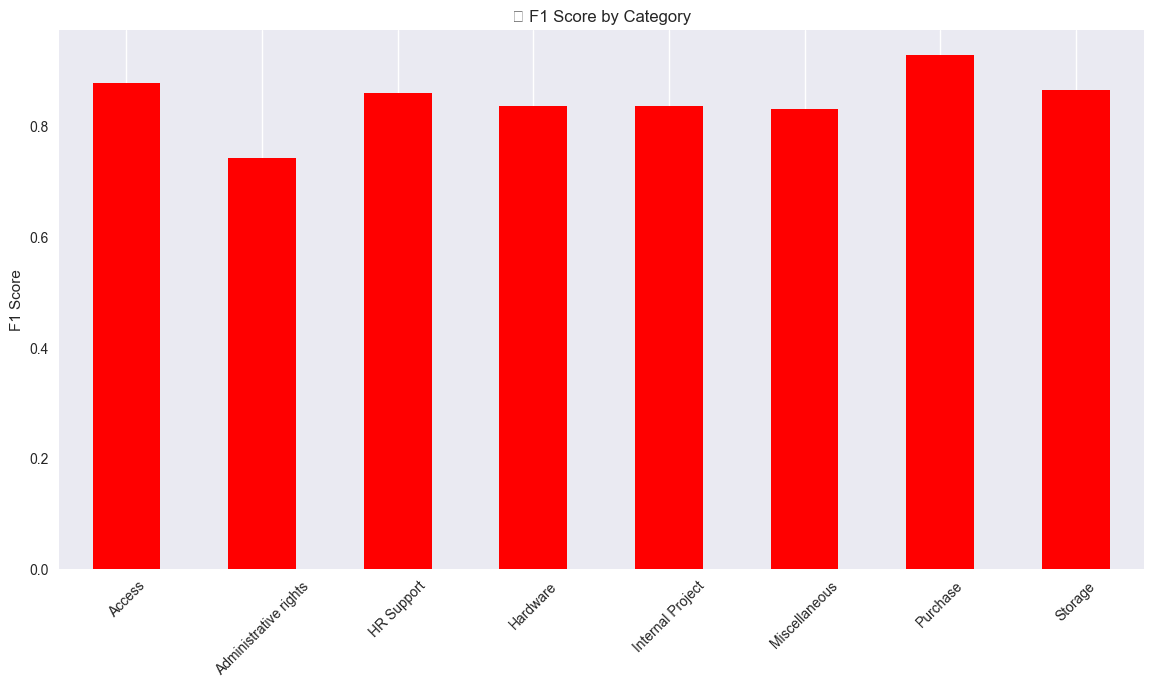

In [21]:
report_df['f1-score'].plot(kind='bar', color='red')

plt.title("📊 F1 Score by Category")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

F1-score balances precision and recall, providing a single metric to evaluate model performance across categories.

Confusion Matrix (Normalized)

c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


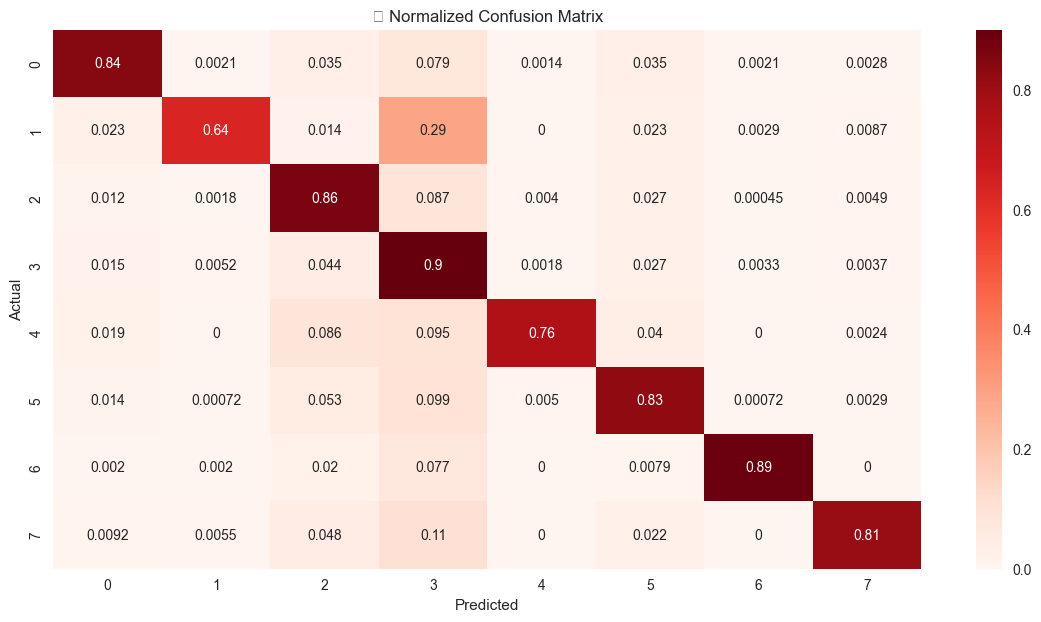

In [22]:
cm = confusion_matrix(y_test, y_pred)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, annot=True, cmap='Reds')

plt.title("📊 Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

This version of the confusion matrix shows percentages instead of raw counts, making it easier to understand classification accuracy per category.

Ticket Length vs Category

c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


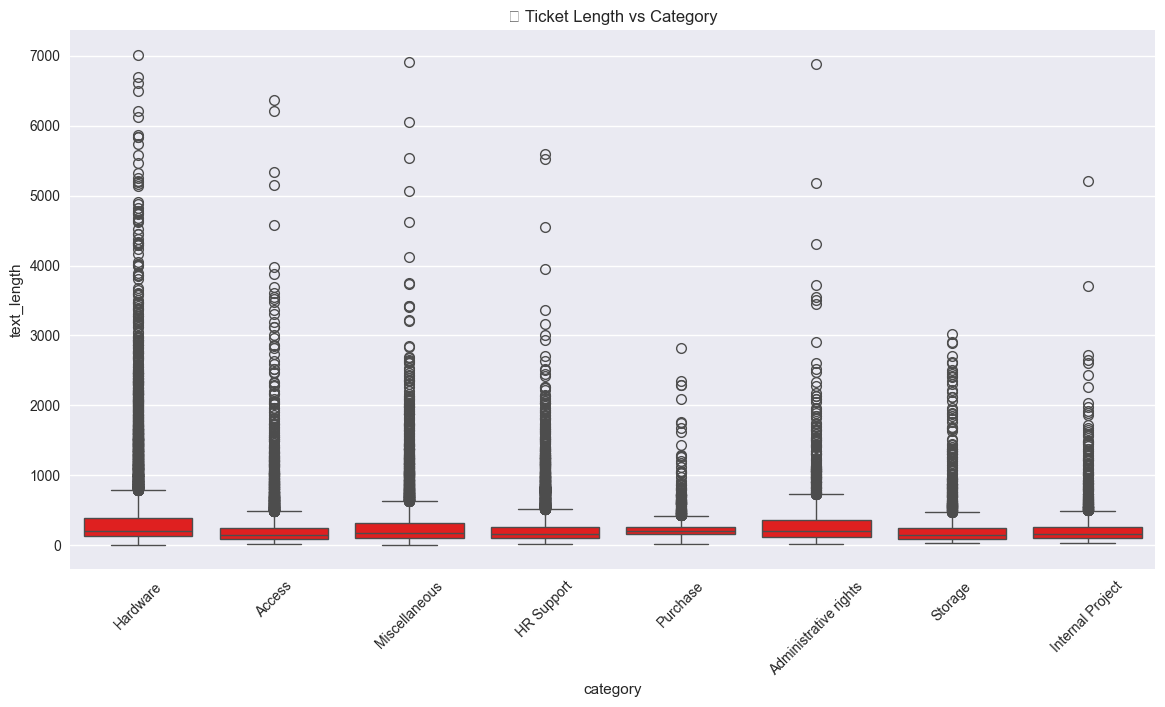

In [23]:
sns.boxplot(x='category', y='text_length', data=df, color='red')

plt.title("📊 Ticket Length vs Category")
plt.xticks(rotation=45)
plt.show()

This graph shows how ticket length varies across categories, helping identify whether certain issues require more detailed descriptions.

Top Words per Category

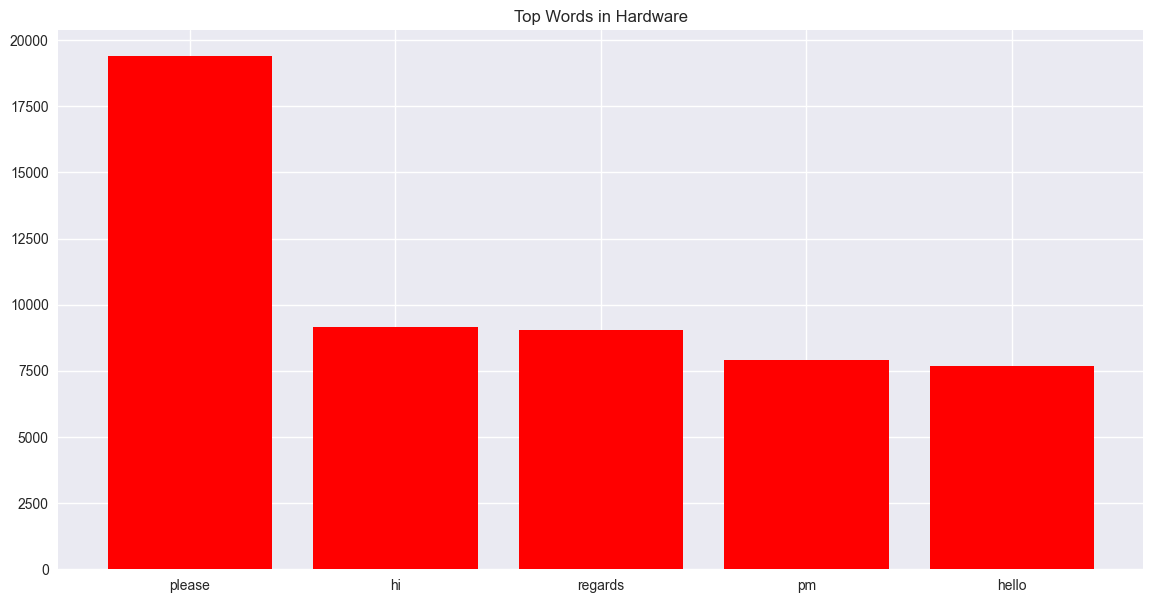

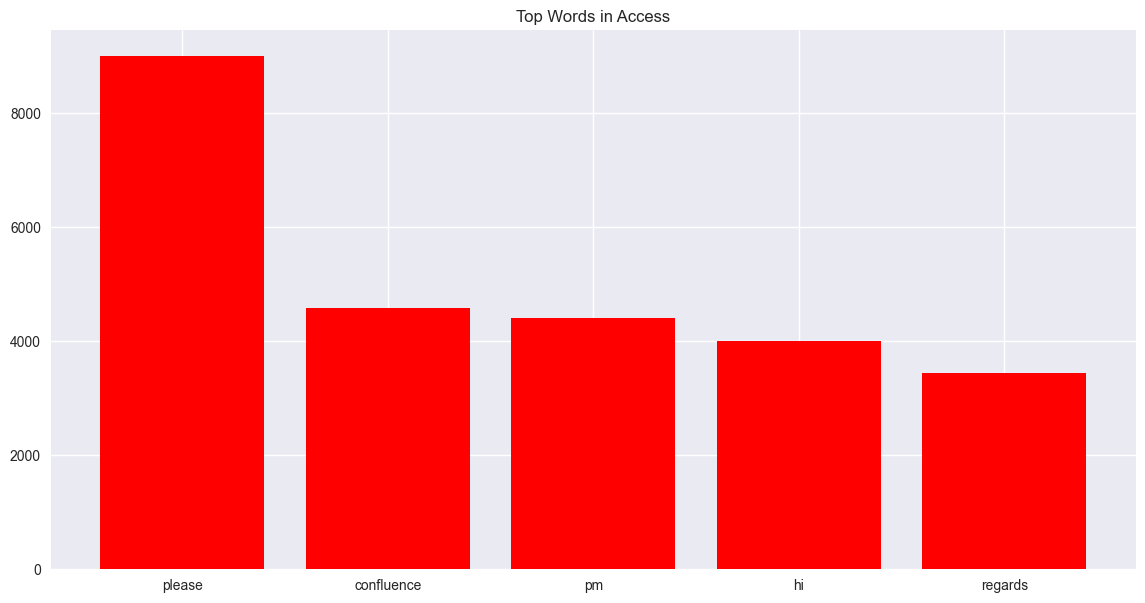

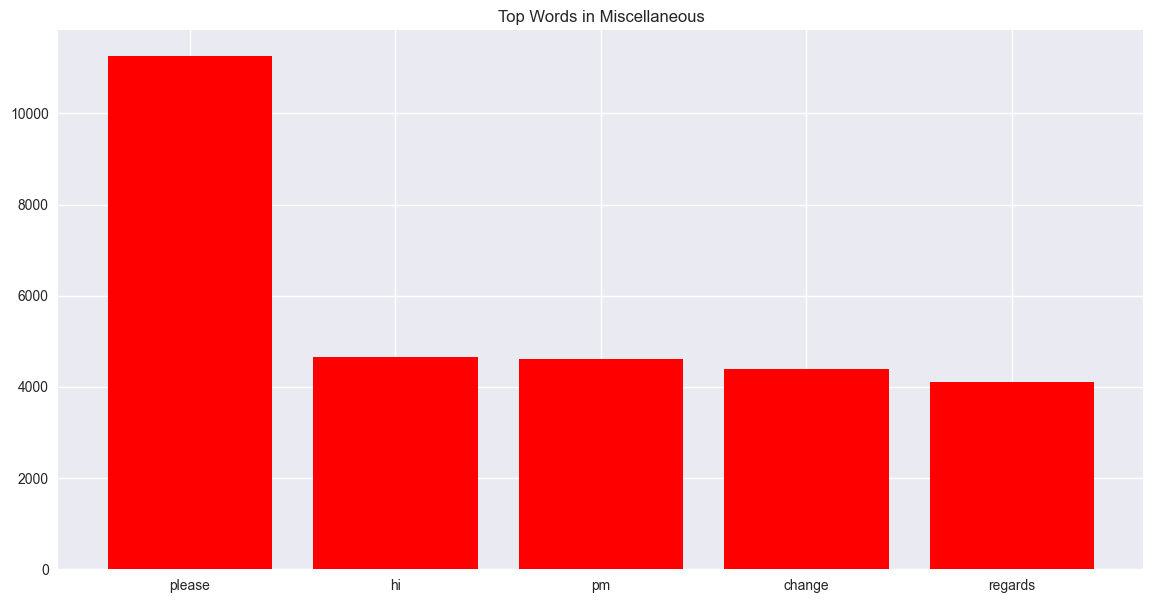

In [24]:
for cat in df['category'].unique()[:3]:
    words = " ".join(df[df['category']==cat]['clean_text']).split()
    
    common = pd.DataFrame(Counter(words).most_common(5), columns=['Word','Count'])
    
    plt.figure()
    plt.bar(common['Word'], common['Count'], color='red')
    
    plt.title(f"Top Words in {cat}")
    plt.show()

This shows frequently used words for each category, helping understand the nature of different types of support issues.

Model Confidence

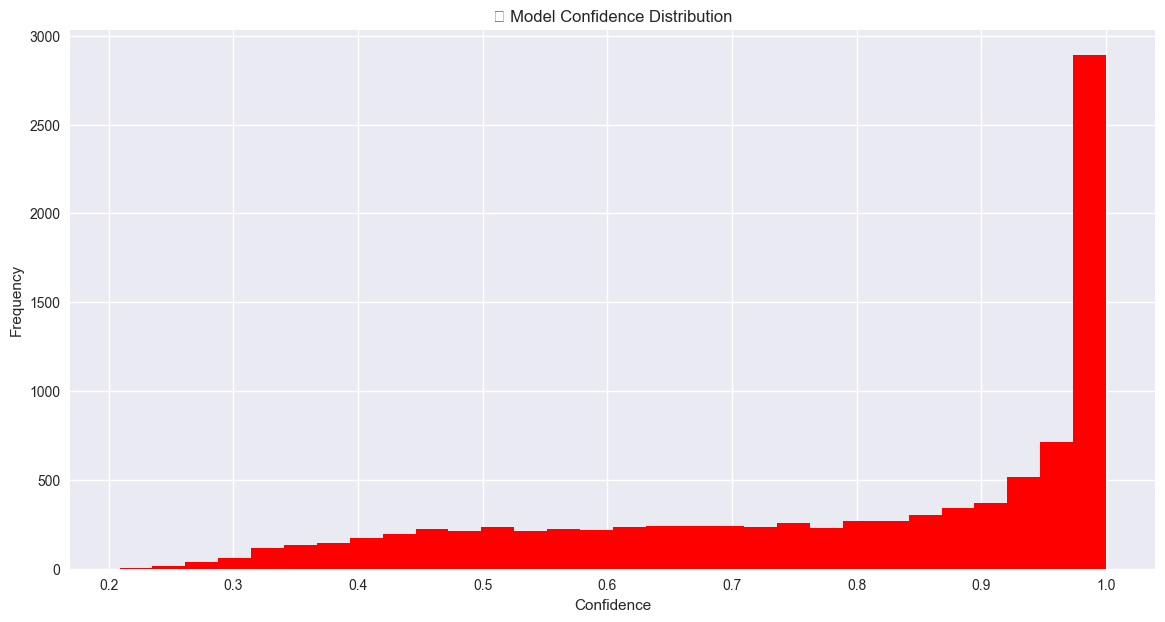

In [25]:
probs = model.predict_proba(X_test)

confidence = np.max(probs, axis=1)

plt.hist(confidence, bins=30, color='red')

plt.title("📊 Model Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

This graph shows how confident the model is in its predictions. Higher confidence indicates more reliable predictions.

In [26]:
class_acc = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True),
    'Predicted': pd.Series(y_pred)
})

class_acc['Correct'] = class_acc['Actual'] == class_acc['Predicted']

In [27]:
for i in range(10):
    print(repr(y_test.iloc[i]), " | ", repr(y_pred[i]))

'HR Support'  |  'HR Support'
'Miscellaneous'  |  'Hardware'
'Miscellaneous'  |  'Miscellaneous'
'Storage'  |  'Storage'
'Storage'  |  'Storage'
'Miscellaneous'  |  'Miscellaneous'
'Miscellaneous'  |  'Miscellaneous'
'Administrative rights'  |  'Administrative rights'
'HR Support'  |  'HR Support'
'Purchase'  |  'Purchase'


In [28]:
y_test_clean = y_test.astype(str).str.strip().str.lower().reset_index(drop=True)
y_pred_clean = pd.Series(y_pred).astype(str).str.strip().str.lower()

class_acc = pd.DataFrame({
    'Actual': y_test_clean,
    'Predicted': y_pred_clean
})

class_acc['Correct'] = class_acc['Actual'] == class_acc['Predicted']

In [29]:
print(class_acc['Correct'].value_counts())

Correct
True     8140
False    1428
Name: count, dtype: int64


Prediction Error Table

In [30]:
errors = class_acc[class_acc['Correct'] == False].head(10)
errors

,Actual,Predicted,Correct
1,miscellaneous,hardware,False
15,internal project,access,False
26,access,storage,False
29,storage,hardware,False
45,access,miscellaneous,False
51,hr support,hardware,False
61,storage,hardware,False
67,access,hardware,False
72,miscellaneous,hardware,False
78,miscellaneous,hardware,False


This table shows incorrectly classified tickets, helping identify patterns where the model fails.

In [31]:
corrects = class_acc[class_acc['Correct'] == True].head(10)
corrects

,Actual,Predicted,Correct
0,hr support,hr support,True
2,miscellaneous,miscellaneous,True
3,storage,storage,True
4,storage,storage,True
5,miscellaneous,miscellaneous,True
6,miscellaneous,miscellaneous,True
7,administrative rights,administrative rights,True
8,hr support,hr support,True
9,purchase,purchase,True
10,hardware,hardware,True
